# ThermoPlume Tutorial

This notebook is an introduction to the ThermoPlume Python model.

It demonstrates:

- defining model parameters
- usign the analytical model
- using the numerical model with the Python implementation
- using the numerical model with the C++ implementation
- comparing all three implementations
- sweeping external-water loading `Omega`
- plotting the critical neutral-buoyancy threshold `xi_crit`

Detailed model, equations, assumptions, and derivations are documented separately in the associated research papers (see GitHub repo for more information). 

## Installation

From the ThermoPlume repository root, install the package as follows:

```bash
python -m pip install -e .
```

The editable install makes changes under `src/thermoplume/` available without reinstalling after every Python edit. The compiled C++ backend is built during installation.


## Imports


In [4]:
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np

from thermoplume import (
    ThermoPlumeModel,
    ThermoPlumeParameters,
)


## Define model parameters

`ThermoPlumeParameters` contains the default thermodynamic and source parameters used by the model. Individual values can be changed when the parameter object is created.


In [6]:
params = ThermoPlumeParameters(
    Omega=0.15,
    T_m=1100.0,
)

params


ThermoPlumeParameters(Omega=0.15, n=0.03, T_m=1100.0, T_air=273.15, T_w=373.15, T_w0=273.15, T_sat=373.15, Cp_air=1004.0, Cp_m=3000.0, Cp_w=1850.0, Cp_l=4180.0, R_air=287.0, R_g=461.5, R_w=461.5, L_v=2500000.0, C=2.0, k=0.05, rho_air=1.2, rho_a=1.2, g=9.81, u0=100.0, D=50.0, Y_air_min=1e-10)

Here, `Omega` controls external-water loading and `T_m` is the source magma temperature in K.


## Create the model


In [9]:
model = ThermoPlumeModel(params)


## Analytical solution

The analytical method evaluates the closed-form neutral-buoyancy solution for the physically admissible thermodynamic regime.


In [11]:
analytical = model.solve(
    method="analytical",
)

analytical


{'xi_crit': np.float64(0.8043373275568234),
 'regime': 'C',
 'method': 'analytical',
 'backend': 'python'}

## Numerical solution with Python

The Python numerical backend scans the physical `xi` interval, brackets neutral-buoyancy roots, and refines them with Brent's method.


In [13]:
numerical_python = model.solve(
    method="numerical",
    backend="python",
)

numerical_python


{'xi_crit': 0.8043373275568237,
 'regime': 'C',
 'method': 'numerical',
 'backend': 'python'}

## Numerical solution with C++

The C++ backend implements the same numerical model in compiled C++ and is exposed to Python through pybind11.


In [15]:
numerical_cpp = model.solve(
    method="numerical",
    backend="cpp",
)

numerical_cpp


{'xi_crit': 0.8043373275568237,
 'regime': 'C',
 'method': 'numerical',
 'backend': 'cpp'}

## Compare the three implementations


In [17]:
comparison = {
    "analytical": analytical["xi_crit"],
    "numerical_python": numerical_python["xi_crit"],
    "numerical_cpp": numerical_cpp["xi_crit"],
}

comparison


{'analytical': np.float64(0.8043373275568234),
 'numerical_python': 0.8043373275568237,
 'numerical_cpp': 0.8043373275568237}

In [18]:
assert np.isclose(
    analytical["xi_crit"],
    numerical_python["xi_crit"],
    rtol=1e-8,
    atol=1e-10,
)

assert np.isclose(
    numerical_python["xi_crit"],
    numerical_cpp["xi_crit"],
    rtol=1e-8,
    atol=1e-10,
)

print("analytical, Python numerical, and C++ numerical solutions agree")


analytical, Python numerical, and C++ numerical solutions agree


## Sweep external-water loading

A simple sweep shows how the critical neutral-buoyancy threshold changes with `Omega`.

Each solver tracks the nearest previous solution so that the sweep follows the same solution branch when multiple admissible roots are possible.


In [20]:
Omega_values = np.linspace(
    0.0,
    0.60,
    121,
)

xi_analytical = []
xi_python = []
xi_cpp = []

previous_analytical = None
previous_python = None
previous_cpp = None

base = ThermoPlumeParameters(
    T_m=1100.0,
)

for Omega in Omega_values:
    p = replace(
        base,
        Omega=float(Omega),
    )

    sweep_model = ThermoPlumeModel(p)

    analytical_result = sweep_model.solve(
        method="analytical",
        previous_xi=previous_analytical,
    )

    python_result = sweep_model.solve(
        method="numerical",
        backend="python",
        previous_xi=previous_python,
    )

    cpp_result = sweep_model.solve(
        method="numerical",
        backend="cpp",
        previous_xi=previous_cpp,
    )

    xi_analytical.append(
        analytical_result["xi_crit"]
    )

    xi_python.append(
        python_result["xi_crit"]
    )

    xi_cpp.append(
        cpp_result["xi_crit"]
    )

    if np.isfinite(analytical_result["xi_crit"]):
        previous_analytical = analytical_result["xi_crit"]

    if np.isfinite(python_result["xi_crit"]):
        previous_python = python_result["xi_crit"]

    if np.isfinite(cpp_result["xi_crit"]):
        previous_cpp = cpp_result["xi_crit"]

xi_analytical = np.asarray(xi_analytical)
xi_python = np.asarray(xi_python)
xi_cpp = np.asarray(xi_cpp)


## Plot the neutral-buoyancy threshold


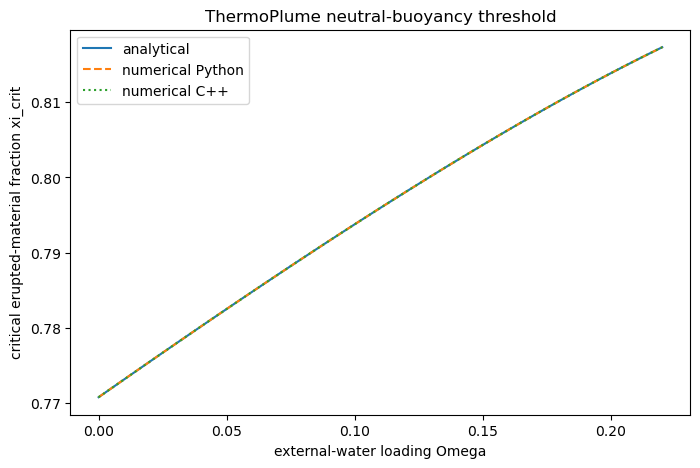

In [22]:
fig, ax = plt.subplots(
    figsize=(8, 5),
)

ax.plot(
    Omega_values,
    xi_analytical,
    label="analytical",
)

ax.plot(
    Omega_values,
    xi_python,
    "--",
    label="numerical Python",
)

ax.plot(
    Omega_values,
    xi_cpp,
    ":",
    label="numerical C++",
)

ax.set_xlabel("external-water loading Omega")
ax.set_ylabel("critical erupted-material fraction xi_crit")
ax.set_title("ThermoPlume neutral-buoyancy threshold")
ax.legend()

plt.show()


## Numerical agreement across the sweep

The following cells compare the numerical implementations wherever both return finite roots.


In [24]:
finite_python_cpp = (
    np.isfinite(xi_python)
    & np.isfinite(xi_cpp)
)

max_cpp_difference = np.max(
    np.abs(
        xi_python[finite_python_cpp]
        - xi_cpp[finite_python_cpp]
    )
)

max_cpp_difference


np.float64(9.027223413227148e-13)

In [25]:
finite_all = (
    np.isfinite(xi_analytical)
    & np.isfinite(xi_python)
    & np.isfinite(xi_cpp)
)

assert np.allclose(
    xi_analytical[finite_all],
    xi_python[finite_all],
    rtol=1e-8,
    atol=1e-10,
)

assert np.allclose(
    xi_python[finite_all],
    xi_cpp[finite_all],
    rtol=1e-8,
    atol=1e-10,
)

print("all finite sweep solutions agree within tolerance")


all finite sweep solutions agree within tolerance


## Next steps

This tutorial intentionally focuses on the software interface. Future examples can add parameter sweeps over source temperature, solver benchmarks, regime diagnostics, and other workflows.
